In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [11]:
# image_path="/kaggle/input/face-expression-recognition-dataset/images/train"

# train_path="/kaggle/input/face-expression-recognition-dataset/images/train"
# valid_path="/kaggle/input/face-expression-recognition-dataset/images/validation"

image_path="C:/ALL/Project Final year/new facial/images/train"

train_path="C:/ALL/Project Final year/new facial/images/train"
valid_path="C:/ALL/Project Final year/new facial/images/validation"

In [12]:
import os

# Correctly formatted image path
image_path = r'C:/ALL/Project Final year/new facial/images/train'  # Using raw string

# Check if the path exists
if os.path.exists(image_path):
    # Define the list of class names (folders) only if the path exists
    class_names = [folder for folder in os.listdir(image_path) if os.path.isdir(os.path.join(image_path, folder))]
    print("Class names (folders):", class_names)
else:
    print(f"The specified path does not exist: {image_path}")


Class names (folders): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [13]:
class_names

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [14]:
number_of_images = {}
for class_name in class_names:
    number_of_images[class_name] = len(os.listdir(image_path+"/"+class_name))

images_per_class = pd.DataFrame(list(number_of_images.items()), columns=['Class Name', 'Number of Images'])
images_per_class

,Class Name,Number of Images
0,angry,3993
1,disgust,436
2,fear,4103
3,happy,7164
4,neutral,4982
5,sad,4938
6,surprise,3205


In [15]:
# Training data generator with data augmentation
traindata_generator = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data generator (rescaling only)
validdata_generator = ImageDataGenerator(rescale=1./255)

In [16]:
import os
from keras.preprocessing.image import ImageDataGenerator

# Correctly formatted paths (using raw strings)
# train_path = r'C:\ALL\Project Final year\new facial\images\train'  # Example path for training data
# valid_path = r'C:\ALL\Project Final year\new facial\images\valid'  # Example path for validation data
train_path="C:/ALL/Project Final year/new facial/images/train"
valid_path="C:/ALL/Project Final year/new facial/images/validation"

# Check if the training and validation directories exist
if not os.path.exists(train_path):
    raise OSError(f"Training directory does not exist: {train_path}")

if not os.path.exists(valid_path):
    raise OSError(f"Validation directory does not exist: {valid_path}")

# Initialize ImageDataGenerator
traindata_generator = ImageDataGenerator(rescale=1./255)
validdata_generator = ImageDataGenerator(rescale=1./255)

# Training data
train_generator = traindata_generator.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Validation data
validation_generator = validdata_generator.flow_from_directory(
    valid_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


In [17]:
# Load MobileNetV2 with pre-trained weights and exclude the top layers
mobilenetV2_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [18]:
# Freeze the base model
for layer in mobilenetV2_model.layers:
    layer.trainable = False
    
# Adding custom layers on top of the base model
x = mobilenetV2_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
prediction = Dense(7, activation='softmax')(x)

In [19]:
# Create the final model
model = Model(inputs=mobilenetV2_model.input, outputs=prediction)

In [20]:
# Compile the model
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
# Model summary
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']        

In [22]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

In [23]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20
901/901 [==============================] - 915s 1s/step - loss: 1.5777 - accuracy: 0.4097 - val_loss: 1.4619 - val_accuracy: 0.4468 - lr: 0.0010
Epoch 2/20
901/901 [==============================] - 966s 1s/step - loss: 1.4182 - accuracy: 0.4613 - val_loss: 2.3023 - val_accuracy: 0.3163 - lr: 0.0010
Epoch 3/20
901/901 [==============================] - 953s 1s/step - loss: 1.3660 - accuracy: 0.4805 - val_loss: 1.4902 - val_accuracy: 0.4316 - lr: 0.0010
Epoch 4/20
901/901 [==============================] - 969s 1s/step - loss: 1.3386 - accuracy: 0.4888 - val_loss: 2.6741 - val_accuracy: 0.2288 - lr: 0.0010
Epoch 5/20
901/901 [==============================] - 1030s 1s/step - loss: 1.2507 - accuracy: 0.5282 - val_loss: 1.3606 - val_accuracy: 0.4854 - lr: 2.0000e-04
Epoch 6/20
901/901 [==============================] - 1000s 1s/step - loss: 1.2280 - accuracy: 0.5383 - val_loss: 1.3226 - val_accuracy: 0.5055 - lr: 2.0000e-04
Epoch 7/20
901/901 [==============================] - 

In [24]:
# Unfreeze the base model and fine-tune
for layer in mobilenetV2_model.layers:
    layer.trainable = True

In [25]:
# Compile the model again with a lower learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

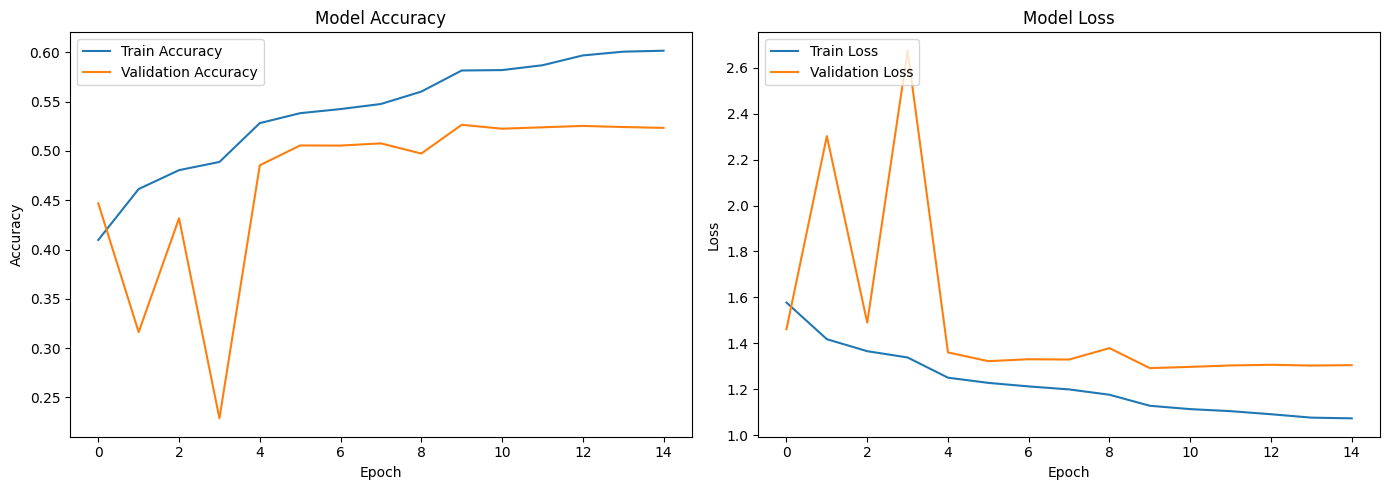

In [27]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [28]:
# Fine-tune the model
fine_tune_history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
901/901 [==============================] - 5979s 7s/step - loss: 1.6098 - accuracy: 0.4010 - val_loss: 1.6399 - val_accuracy: 0.3743 - lr: 1.0000e-05
Epoch 2/10
901/901 [==============================] - 3372s 4s/step - loss: 1.3388 - accuracy: 0.4881 - val_loss: 1.5643 - val_accuracy: 0.4004 - lr: 1.0000e-05
Epoch 3/10
901/901 [==============================] - 3407s 4s/step - loss: 1.2053 - accuracy: 0.5429 - val_loss: 1.5586 - val_accuracy: 0.4002 - lr: 1.0000e-05
Epoch 4/10
901/901 [==============================] - 4945s 5s/step - loss: 1.0992 - accuracy: 0.5884 - val_loss: 1.5589 - val_accuracy: 0.3994 - lr: 1.0000e-05
Epoch 5/10
901/901 [==============================] - 3505s 4s/step - loss: 0.9997 - accuracy: 0.6270 - val_loss: 1.4550 - val_accuracy: 0.4499 - lr: 1.0000e-05
Epoch 6/10
901/901 [==============================] - 3492s 4s/step - loss: 0.9021 - accuracy: 0.6688 - val_loss: 1.3751 - val_accuracy: 0.4963 - lr: 1.0000e-05
Epoch 7/10
901/901 [==============

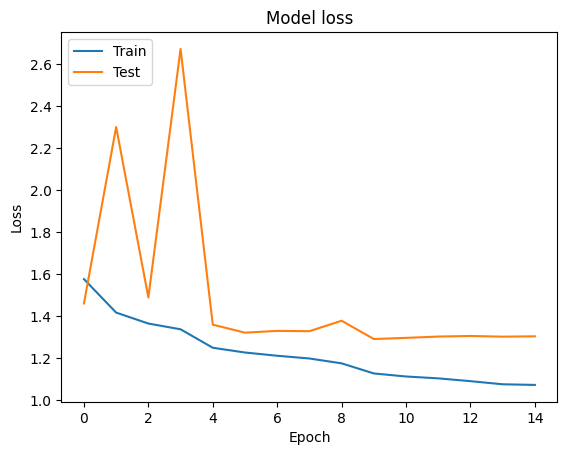

In [29]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

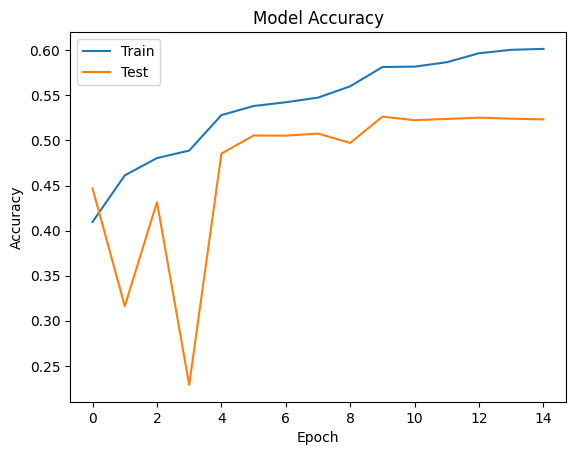

In [30]:
# Plot training & validation loss values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [31]:
true_classes = validation_generator.classes
predicted_classes = np.argmax(model.predict(validation_generator, steps=int(np.ceil(validation_generator.samples / validation_generator.batch_size))), axis=1)
class_labels = list(validation_generator.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

221/221 [==============================] - 293s 1s/step


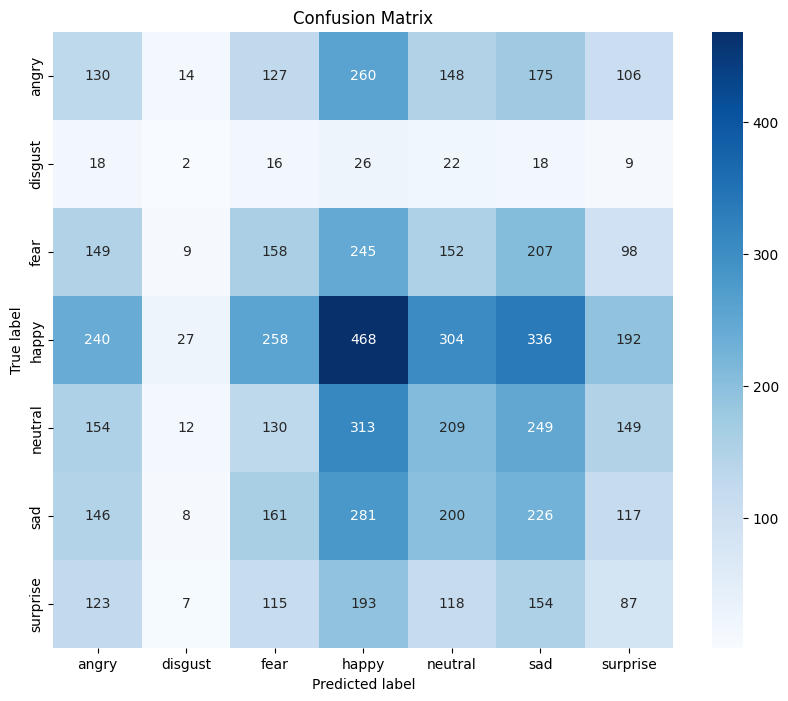

In [32]:
# Plotting confusion matrix with seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [33]:
#classification report
report = classification_report(true_classes,
                               predicted_classes,
                               target_names=class_labels,
                               zero_division=0)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

       angry       0.14      0.14      0.14       960
     disgust       0.03      0.02      0.02       111
        fear       0.16      0.16      0.16      1018
       happy       0.26      0.26      0.26      1825
     neutral       0.18      0.17      0.18      1216
         sad       0.17      0.20      0.18      1139
    surprise       0.11      0.11      0.11       797

    accuracy                           0.18      7066
   macro avg       0.15      0.15      0.15      7066
weighted avg       0.18      0.18      0.18      7066



In [34]:
model.save('emotion_detection_model.h5')

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
